![image.png](https://i.imgur.com/a3uAqnb.png)

# Linear Regression for Walmart Sales Forecasting - Homework Assignment

In this homework, you will implement a **Linear Regression model** to predict weekly sales for Walmart stores using historical data. This project will help you understand the fundamentals of linear regression applied to time series forecasting.

## 📌 Project Overview
- **Task**: Predict weekly sales for Walmart stores
- **Algorithm**: Linear Regression
- **Dataset**: Walmart Store Sales dataset (provided)
- **Goal**: Build an accurate regression model using scikit-learn or custom implementation

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand linear regression for forecasting problems
- Learn data preprocessing and feature engineering for time series
- Practice holiday feature creation and encoding
- Learn about regression metrics and model evaluation
- Understand train/test splitting for time series data

### Dataset Overview

You are provided with a CSV file named **`Walmart_Store_sales.csv`**, containing weekly sales data from **February 5, 2010** to **November 1, 2012**. The dataset includes the following columns:

1. **Store** — Store ID number
2. **Date** — Week of the sales
3. **Weekly\_Sales** — Weekly sales amount for the given store
4. **Holiday\_Flag** — Whether the week included a major holiday

   * `1` = Holiday week
   * `0` = Non-holiday week
5. **Temperature** — Temperature on the day of sale
6. **Fuel\_Price** — Cost of fuel in the region
7. **CPI** — Consumer Price Index
8. **Unemployment** — Unemployment rate in the region

## 1️⃣ Initial Setup and Library Installation

**Task**: Set up the environment and install necessary libraries.

In [ ]:
from IPython.display import clear_output

In [ ]:
# Incase you run this notebook outside colab (where the libraries aren't already pre-installed)

# %pip install pandas
# %pip install numpy
# %pip install scikit-learn
# %pip install matplotlib
# %pip install seaborn

clear_output()

## 2️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import data processing libraries (pandas, numpy)
- Import scikit-learn modules for regression and metrics
- Import visualization libraries
- Set random seeds for reproducibility
- Configure parameters for data splitting and model training

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# os
import os

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Configuration parameters
TEST_SIZE = 0.2              # Test set size (80:20 split)
RANDOM_STATE = 42           # Random state for reproducibility
SCALE_FEATURES = True       # Whether to scale features
PLOT_STYLE = 'seaborn'      # Plotting style

## 3️⃣ Data Loading and Exploration

**Task**: Load the Walmart sales dataset and explore its structure.

**Requirements**:
- Download and load the dataset
- Display basic information about the data
- Check for missing values and data types
- Understand the features and target variable
- Explore the date range and holiday patterns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/walmart-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'walmart-dataset' dataset.
Path to dataset files: /kaggle/input/walmart-dataset


In [ ]:
# TODO: Load the dataset
data_df = pd.read_csv(os.path.join(path, "Walmart.csv")) # not named 'Walmart_Store_sales.csv' !!!

# TODO: Display basic information about the dataset
'''
already displayed in the next few TODOs
'''

'\nalready displayed in the next few TODOs\n'

In [ ]:
# TODO: Check the shape of the dataset
print(data_df.shape)

# TODO: Display first few rows
display(data_df.head())

# TODO: Check data types and info
display(data_df.info())

(6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

In [ ]:
# TODO: Check for missing values
display(data_df.isna().head())
display(data_df.isna().sum())

# TODO: Display basic statistics
display(data_df.describe()) #.describe() for getting basicstatistics

# TODO: Check unique stores and date range
print(data_df['Store'].unique())
print(data_df['Store'].nunique()) # .nunique() -- > get the amount of unique values#
print(data_df['Date'].min(), data_df['Date'].max())

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
45
01-04-2011 31-12-2010


## 4️⃣ Data Preprocessing and Feature Engineering

**Task**: Clean and prepare the data for linear regression training.

**Requirements**:
- Handle missing values if any
- Convert date column to datetime format
- Create holiday type features based on specific dates
- Extract time-based features from dates
- Handle categorical variables
- Prepare features and target variables

In [ ]:
# TODO: Create a copy of the data for preprocessing
processed_data = data_df.copy()

# ADD_TODO: Display first few rows of the processed data (to check)
'''
display(processed_data.head())
'''

# TODO: Convert Date column to datetime format
processed_data['Date'] = pd.to_datetime(processed_data['Date'], format='%d-%m-%Y')

# TODO: Handle any missing values
'''
No missing values found in the dataset.
'''

'\nNo missing values found in the dataset.\n'

In [ ]:
# TODO: Create holiday mapping function
def get_holiday_type(date):
    """
    Map dates to specific holiday types based on the given holiday dates:
    - Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
    - Labour Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
    - Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
    - Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13
    """
    # align the format of datetime
    date = pd.to_datetime(date, format='%d-%m-%Y')

    super_bowl_dates = [pd.to_datetime('12-02-2010', format='%d-%m-%Y').date(),
                        pd.to_datetime('11-02-2011', format='%d-%m-%Y').date(),
                        pd.to_datetime('10-02-2012', format='%d-%m-%Y').date(),
                        pd.to_datetime('08-02-2013', format='%d-%m-%Y').date()]

    labour_day_dates = [pd.to_datetime('10-09-2010', format='%d-%m-%Y').date(),
                        pd.to_datetime('09-09-2011', format='%d-%m-%Y').date(),
                        pd.to_datetime('07-09-2012', format='%d-%m-%Y').date(),
                        pd.to_datetime('06-09-2013', format='%d-%m-%Y').date()]

    thanksgiving_dates = [pd.to_datetime('26-11-2010', format='%d-%m-%Y').date(),
                          pd.to_datetime('25-11-2011', format='%d-%m-%Y').date(),
                          pd.to_datetime('23-11-2012', format='%d-%m-%Y').date(),
                          pd.to_datetime('29-11-2013', format='%d-%m-%Y').date()]

    christmas_dates = [pd.to_datetime('31-12-2010', format='%d-%m-%Y').date(),
                       pd.to_datetime('30-12-2011', format='%d-%m-%Y').date(),
                       pd.to_datetime('28-12-2012', format='%d-%m-%Y').date(),
                       pd.to_datetime('27-12-2013', format='%d-%m-%Y').date()]

    # TODO: Implement holiday mapping logic
    if date in super_bowl_dates:
        return 'Super_Bowl'
    elif date in labour_day_dates:
        return 'Labour_Day'
    elif date in thanksgiving_dates:
        return 'Thanksgiving'
    elif date in christmas_dates:
        return 'Christmas'
    else:
        return 'No_Holiday'

# TODO: Apply holiday mapping to create new feature
processed_data['Holiday_Type'] = processed_data['Date'].apply(get_holiday_type)

# ADD_TODO: Display first few rows of the processed data (to check)
display(processed_data.head())
display(processed_data.shape)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Type
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,No_Holiday
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,No_Holiday
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,No_Holiday
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,No_Holiday
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,No_Holiday


(6435, 9)

In [ ]:
# TODO: Create additional time-based features (optional)
# Examples: month, quarter, week of year, etc. （choose first three new features）
processed_data['Month'] = processed_data['Date'].dt.month
processed_data['Year'] = processed_data['Date'].dt.year
processed_data['Quarter'] = processed_data['Date'].dt.quarter

# TODO: Encode categorical variables (holiday types)
#implement one-hot encoding

processed_data = pd.get_dummies(processed_data, columns=['Holiday_Type'], prefix='Holiday')

# TODO: Remove unnecessary columns (like original Date if converted)
# 1. remove Date
processed_data.drop('Date', axis=1, inplace=True)

# 2. remove Holiday_Type
'''
already removed in the previous TODO (one-hot encoding)
'''

display(processed_data.shape)

(6435, 11)

in the end, we got 11-1 = 10 features.

could be too less if underfitting.

## 5️⃣ Data Splitting and Preprocessing

**Task**: Split the data and prepare features for linear regression.

**Requirements**:
- Separate features from target variable
- Split data into training and testing sets (80:20)
- Scale features if necessary
- Ensure proper data types for regression

In [ ]:
# TODO: Separate features and target

# Target variable: Weekly_Sales
y = processed_data['Weekly_Sales'] # Target

# Features: All other relevant columns
X = processed_data.drop('Weekly_Sales', axis=1) # Features (drop y)

# TODO: Display feature names and target info
print("--- Feature Information ---")
print(f"Total number of features: {len(X.columns)}")
print(f"Feature names: {X.columns.tolist()}")

print("\n--- Target Information ---")
print(f"Target variable name: {y.name}")

print("\n--- Dataset Shapes ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

--- Feature Information ---
Total number of features: 10
Feature names: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Quarter', 'Holiday_No_Holiday']

--- Target Information ---
Target variable name: Weekly_Sales

--- Dataset Shapes ---
X shape: (6435, 10)
y shape: (6435,)


In [ ]:
# TODO: Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# TODO: Display split informationprint("--- Data Split Information ---")
print(f"Training set shape (X_train): {X_train.shape}")
print(f"Testing set shape (X_test):   {X_test.shape}")
print(f"Training target shape (y_train): {y_train.shape}")
print(f"Testing target shape (y_test):   {y_test.shape}")

Training set shape (X_train): (5148, 10)
Testing set shape (X_test):   (1287, 10)
Training target shape (y_train): (5148,)
Testing target shape (y_test):   (1287,)


In [ ]:
# TODO: Scale features if needed (optional but recommended)

# use standardization rather than normalization here
scaler = StandardScaler()

# TODO: Apply scaling to training and test sets if using scaler
# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization and metadata maintenance
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# TODO: Display shapes of final datasets
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape: {X_test.shape}")

Final X_train shape: (5148, 10)
Final X_test shape: (1287, 10)


## 6️⃣ Model Training

**Task**: Train a linear regression model on the prepared data.

**Requirements**:
- Initialize Linear Regression model
- Train the model on training data
- Display model coefficients and intercept

In [ ]:
# TODO: Initialize Linear Regression model
model = LinearRegression()

# TODO: Train the model
model.fit(X_train, y_train)

# TODO: Display model information (coefficients, intercept)
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
display(coeff_df)

print(f"Intercept (b0): {model.intercept_:,.2f}")


--- Model Coefficients ---


,Feature,Coefficient
6,Month,136517.973638
3,Fuel_Price,14122.029062
1,Holiday_Flag,8029.362911
9,Holiday_No_Holiday,0.000000
7,Year,-15282.089407
2,Temperature,-27747.880734
5,Unemployment,-44936.950969
4,CPI,-84988.913953
8,Quarter,-91982.614187
0,Store,-196105.275192


Intercept (b0): 1,044,996.41


## 7️⃣ Model Evaluation

**Task**: Evaluate the trained model using appropriate regression metrics.

**Requirements**:
- Make predictions on both training and test sets
- Calculate Mean Absolute Error (MAE)
- Calculate Root Mean Squared Error (RMSE)
- Calculate R-squared score
- Compare training vs test performance

In [ ]:
# TODO: Make predictions on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# check fist five predictions on test
print("First 5 predictions (Test Set):")
print(y_test_pred[:5])

First 5 predictions (Test Set):
[1188473.18354537 1131419.62824305 1287406.14571216 1183329.10396844
  733967.62175184]


In [ ]:
# TODO: Calculate evaluation metrics for training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# TODO: Calculate evaluation metrics for test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# TODO: Display results in a formatted way
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Train': [train_mae, train_rmse, train_r2],
    'Test': [test_mae, test_rmse, test_r2]
})

print("--- Model Evaluation Metrics ---")
display(metrics_df.style.format({'Train': '{:,.2f}', 'Test': '{:,.2f}'}))

--- Model Evaluation Metrics ---


,Metric,Train,Test
0,MAE,"428,515.76","432,995.51"
1,RMSE,"519,916.27","521,607.23"
2,R2 Score,0.15,0.16


**R2 score** both very low --> <font color='red'>**Underfitting!**</font>

## 8️⃣ Visualization and Analysis

**Task**: Create visualizations to analyze model performance and results.

**Requirements**:
- Plot predicted vs actual values
- Visualize feature importance (coefficients)
- Show sample predictions

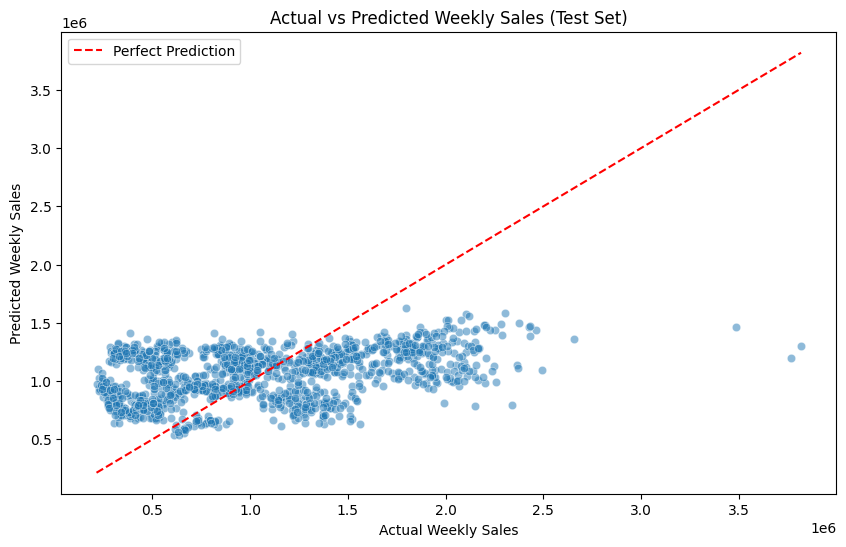

In [ ]:
plt.figure(figsize=(10, 6))

# TODO: Create predicted vs actual scatter plot for test set
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)

# TODO: Add perfect prediction line for reference (=)
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales (Test Set)')
plt.legend()
plt.show()


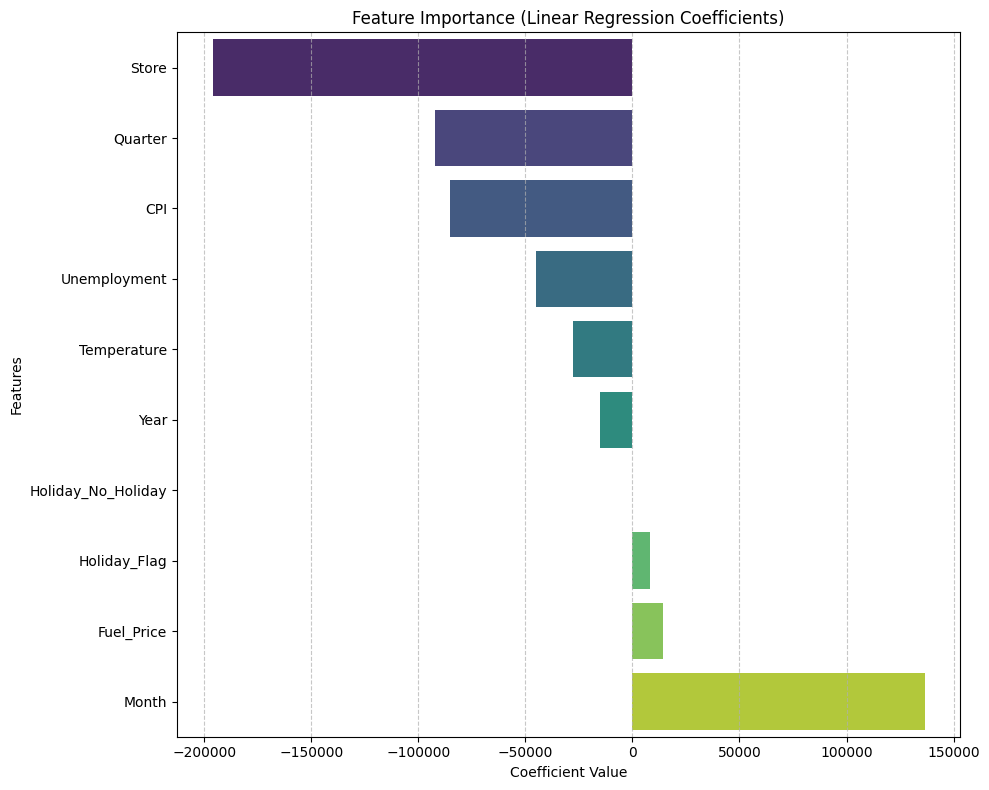

In [ ]:
# TODO: Visualize feature importance (model coefficients)
# first sort
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=True)

# TODO: Create bar plot of feature coefficients
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette='viridis')

plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Show sample predictions vs actual values
# Create a comparison DataFrame for the first 10 test samples
sample_comparison = pd.DataFrame({
    'Actual Sales': y_test.values[:10],
    'Predicted Sales': y_test_pred[:10],
    'Difference': y_test.values[:10] - y_test_pred[:10],
    'Percentage Error (%)': np.abs((y_test.values[:10] - y_test_pred[:10]) / y_test.values[:10]) * 100
})


# TODO: Display first 10 predictions with actual values in a nice format
display(sample_comparison.style.format({
    'Actual Sales': '${:,.2f}',
    'Predicted Sales': '${:,.2f}',
    'Difference': '${:,.2f}',
    'Percentage Error (%)': '{:.2f}%'
}))

,Actual Sales,Predicted Sales,Difference,Percentage Error (%)
0,"$1,138,800.32","$1,188,473.18","$-49,672.86",4.36%
1,"$1,304,850.67","$1,131,419.63","$173,431.04",13.29%
2,"$1,769,296.25","$1,287,406.15","$481,890.10",27.24%
3,"$1,077,640.13","$1,183,329.10","$-105,688.97",9.81%
4,"$428,851.99","$733,967.62","$-305,115.63",71.15%
5,"$1,004,523.59","$914,424.75","$90,098.84",8.97%
6,"$1,523,410.71","$958,915.21","$564,495.50",37.05%
7,"$1,014,898.78","$1,157,766.07","$-142,867.29",14.08%
8,"$1,955,896.59","$986,297.56","$969,599.03",49.57%
9,"$958,667.23","$1,201,163.37","$-242,496.14",25.30%


## Analysis of Results
The low R² score indicates a significant state of **Underfitting**. This suggests that the relationship between the features (like CPI, Unemployment, and Temperature) and Weekly Sales is highly non-linear, or that critical predictors (such as specific store promotions or local events) are missing from the dataset. While the current linear model serves as a useful baseline, future improvements should focus on:
1. **Advanced Modeling**: Implementing non-linear algorithms such as Random Forest, XGBoost, or Prophet for time-series forecasting.
2. **Feature Expansion**: Applying One-Hot Encoding to the `Store` IDs to account for the unique baseline sales of each location.
3. **Residual Analysis**: Investigating specific periods where the model fails most significantly (e.g., peak holiday spikes).

## <font color='red'>**Further Improvement on Feature Engineering**</font>


### **1. Add one-hot coding to 'Store' ID**


In [ ]:
processed_data_improved = pd.get_dummies(processed_data, columns=['Store'], prefix='Store')

### **2. Add time features**



In [ ]:
# 1. Extract week of year to capture seasonality more precisely than months
processed_data_improved['Week'] = data_df['Date'].apply(lambda x: pd.to_datetime(x, format='%d-%m-%Y').week)
'''
1. .apply() works as a for-loop
2. lambda for def the function using only once
'''

# 2. Calculate days to the nearest holiday
holiday_dates = [
    '12-02-2010', '11-02-2011', '10-02-2012', '08-02-2013', # Super Bowl
    '10-09-2010', '09-09-2011', '07-09-2012', '06-09-2013', # Labour Day
    '26-11-2010', '25-11-2011', '23-11-2012', '29-11-2013', # Thanksgiving
    '31-12-2010', '30-12-2011', '28-12-2012', '27-12-2013'  # Christmas
]
holiday_timestamps = pd.to_datetime(holiday_dates, format='%d-%m-%Y')

def days_to_nearest_holiday(current_date):
    current_date = pd.to_datetime(current_date, format='%d-%m-%Y')

    # Calculate absolute differences between current date and all holiday dates
    diffs = [(h - current_date).days for h in holiday_timestamps]

    # Find the minimum absolute difference (closest holiday in past or future)
    return min(diffs, key=abs)

# Positive value means holiday is in the future, negative means holiday just passed
processed_data_improved['Days_to_Holiday'] = data_df['Date'].apply(days_to_nearest_holiday)



### **3. Combine Economics Features**

Economic Interaction Features are advanced predictors created by multiplying two or more individual variables to capture their combined synergistic effects on the target variable.

In [ ]:
# Combining Unemployment and CPI to create an 'Economic Stress Index'
processed_data_improved['Economic_Stress'] = processed_data_improved['Unemployment'] * processed_data_improved['CPI']

# Combining Temperature and Fuel Price
processed_data_improved['Weather_Cost_Impact'] = processed_data_improved['Temperature'] * processed_data_improved['Fuel_Price']

### **4. Add rolling statistics**

observe pattern in a relatively longer period of time

In [ ]:
processed_data_improved['Store'] = data_df['Store']
processed_data_improved['Date'] = pd.to_datetime(data_df['Date'], format='%d-%m-%Y')

# Ensure data is sorted by Store and Date
processed_data_improved = processed_data_improved.sort_values(['Store', 'Date'])

# A. Temperature trend
processed_data_improved['Temp_Rolling_Mean_4'] = processed_data_improved.groupby('Store')['Temperature']\
    .transform(lambda x: x.rolling(window=4).mean())

# B. Sales Lag & Rolling Mean
processed_data_improved['Sales_Lag_1'] = processed_data_improved.groupby('Store')['Weekly_Sales'].shift(1)
processed_data_improved['Sales_Rolling_Mean_4'] = processed_data_improved.groupby('Store')['Weekly_Sales']\
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
'''
  1. use shift(1) to avoid data leakage (using today's sales to predict today)
  2. use window to capture the span
'''

# C. CPI Trend
processed_data_improved['CPI_Rolling_Std_4'] = processed_data_improved.groupby('Store')['CPI']\
    .transform(lambda x: x.rolling(window=4).std())

# Handle NaNs created by the rolling windows
cols_to_fix = ['Temp_Rolling_Mean_4', 'Sales_Lag_1', 'Sales_Rolling_Mean_4', 'CPI_Rolling_Std_4']
for col in cols_to_fix:
    processed_data_improved[col] = processed_data_improved.groupby('Store')[col].transform(lambda x: x.fillna(method='bfill'))

#### **Check current features**

In [ ]:
display(processed_data_improved.shape)
display(processed_data_improved.head())

(6435, 65)

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Quarter,Holiday_No_Holiday,...,Week,Days_to_Holiday,Economic_Stress,Weather_Cost_Impact,Store,Date,Temp_Rolling_Mean_4,Sales_Lag_1,Sales_Rolling_Mean_4,CPI_Rolling_Std_4
0,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,1,True,...,5,7,1711.147080,108.82132,1,2010-02-05,41.8450,1643690.90,1576836.025,0.098920
1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,1,True,...,6,0,1712.329028,98.12348,1,2010-02-12,41.8450,1643690.90,1576836.025,0.098920
2,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,1,True,...,7,-7,1712.709792,100.38402,1,2010-02-19,41.8450,1641957.44,1576836.025,0.098920
3,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,1,True,...,8,-14,1712.957025,119.41943,1,2010-02-26,41.8450,1611968.17,1576836.025,0.098920
4,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,1,True,...,9,-21,1713.204258,122.06250,1,2010-03-05,42.8925,1409727.59,1576836.025,0.046051


**65-1 = 64 features but 45s for store's hot-encoding**

## <font color = 'red'> **Re-training with Improved Features** </font>

In [ ]:
if 'Date' in processed_data_improved.columns:
    processed_data_improved.drop('Date', axis=1, inplace=True)

# 1. Prepare Features (X) and Target (y)
# We use the improved dataframe with 64 features
y_improved = processed_data_improved['Weekly_Sales']
X_improved = processed_data_improved.drop('Weekly_Sales', axis=1)

# 2. Split into Training and Testing sets
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y_improved, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# 3. Scale the features
scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

# 4. Initialize and Train the Model
model_improved = LinearRegression()
model_improved.fit(X_train_imp_scaled, y_train_imp)

# 5. Make Predictions and Evaluate
y_pred_imp = model_improved.predict(X_test_imp_scaled)

# Calculate metrics
new_r2 = r2_score(y_test_imp, y_pred_imp)
new_mae = mean_absolute_error(y_test_imp, y_pred_imp)

print(f"New R2 Score: {new_r2:.4f} (Baseline was ~0.15)")
print(f"New MAE: ${new_mae:,.2f}")

# Compare with baseline
print(f"R2 Improvement: {((new_r2 - 0.1555) / 0.1555) * 100:.2f}%")

New R2 Score: 0.9388 (Baseline was ~0.15)
New MAE: $81,034.27
R2 Improvement: 503.70%


### **1. Training Results**

--- Top 10 Most Impactful Features (Improved Model) ---


,Feature,Coefficient
3,CPI,352043.518211
5,Month,224005.325613
61,Sales_Rolling_Mean_4,199324.597197
54,Week,-160841.880195
21,Store_13,137305.493207
12,Store_4,136149.583091
18,Store_10,128832.814567
13,Store_5,-125491.033965
11,Store_3,-117832.562891
38,Store_30,-114626.412046


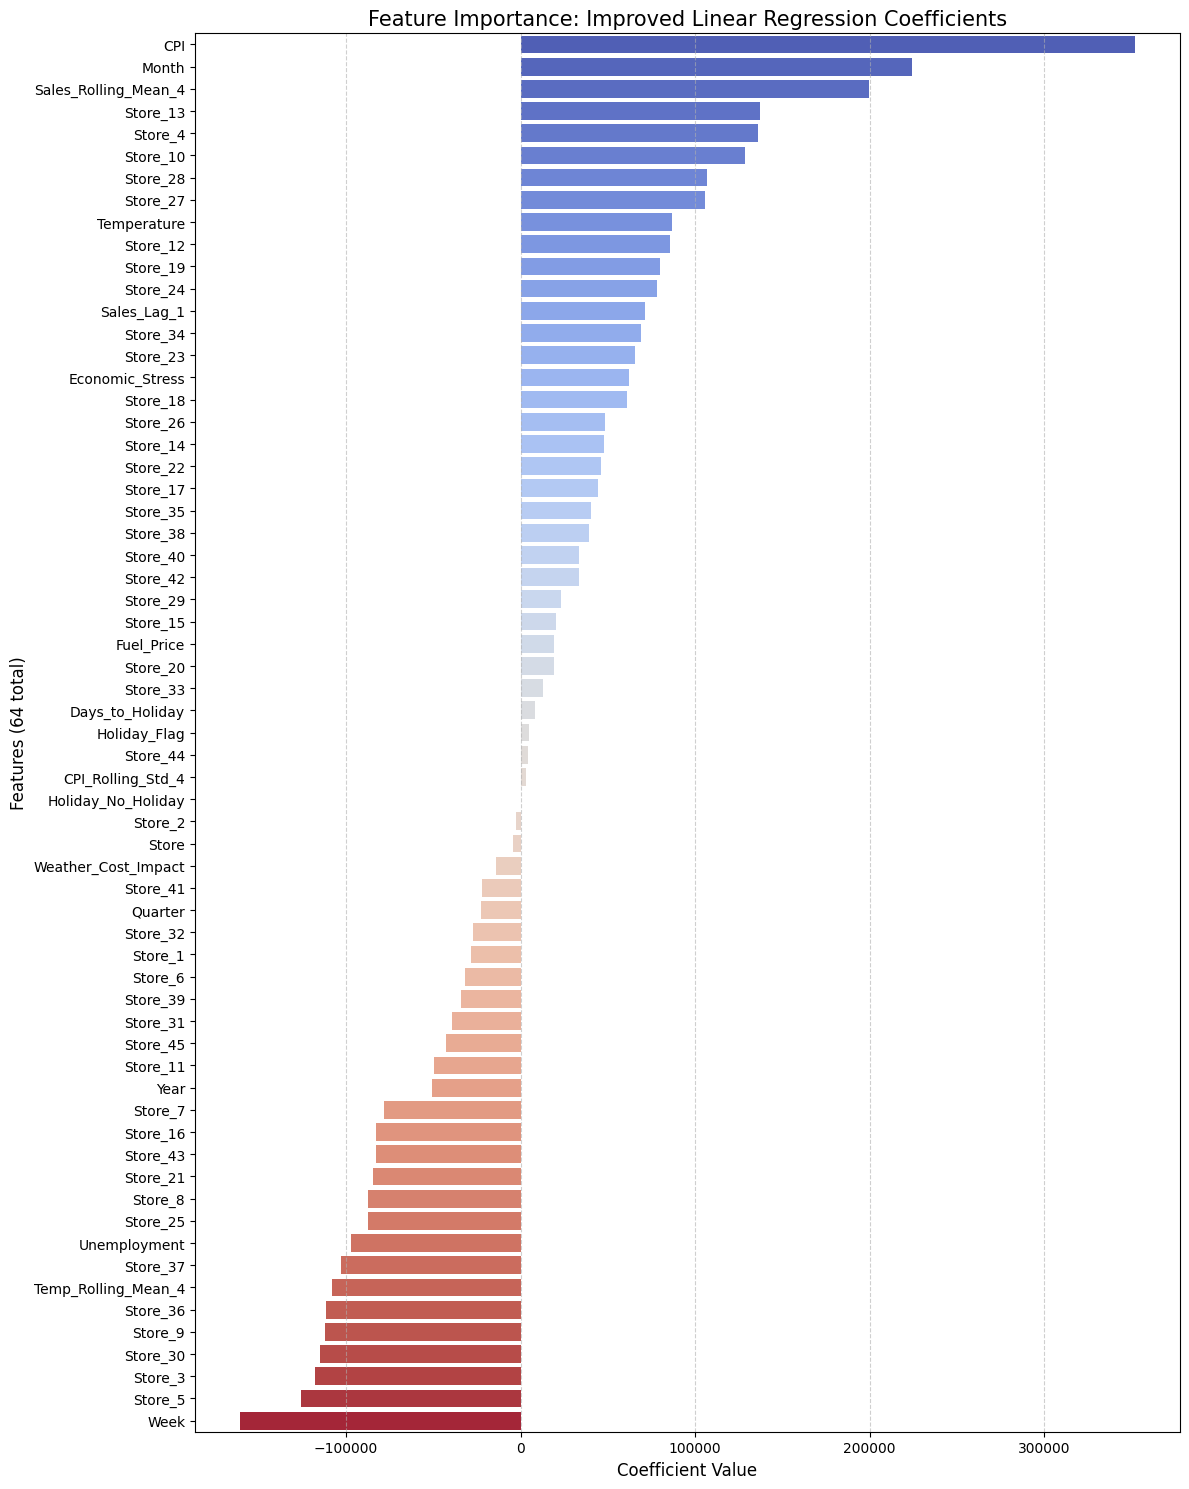

In [ ]:
# 1. Create a DataFrame for model coefficients
coeff_improved_df = pd.DataFrame({
    'Feature': X_improved.columns,
    'Coefficient': model_improved.coef_
})

# 2. Sort by absolute value to see the most impactful features
coeff_improved_df['Abs_Coefficient'] = coeff_improved_df['Coefficient'].abs()
coeff_improved_df = coeff_improved_df.sort_values(by='Abs_Coefficient', ascending=False)

print("--- Top 10 Most Impactful Features (Improved Model) ---")
display(coeff_improved_df[['Feature', 'Coefficient']].head(10))

# 3. Visualization
plt.figure(figsize=(12, 15))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coeff_improved_df.sort_values(by='Coefficient', ascending=False),
    palette='coolwarm'
)

plt.title('Feature Importance: Improved Linear Regression Coefficients', fontsize=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features (64 total)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **2. Visualization**

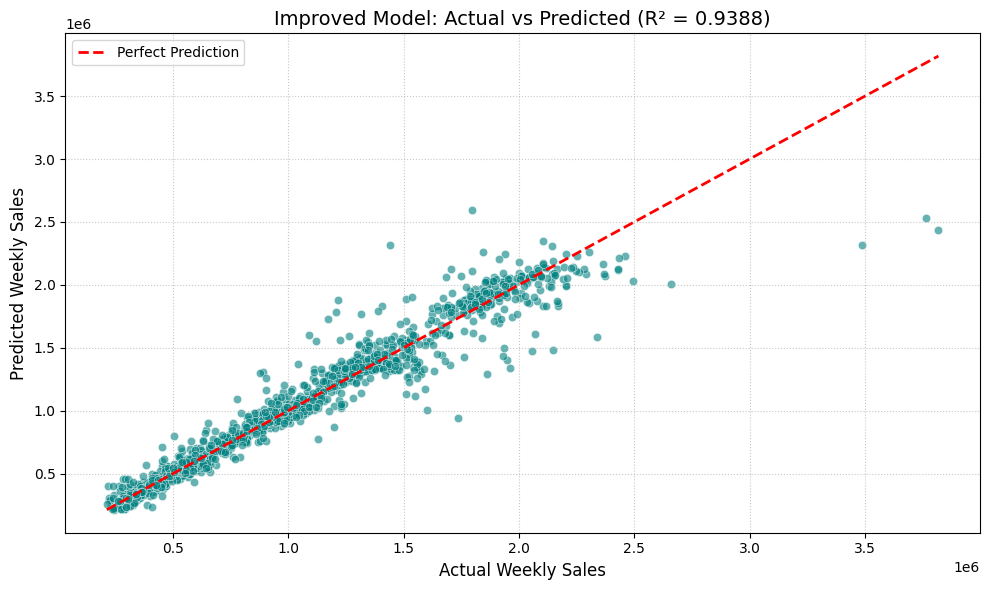

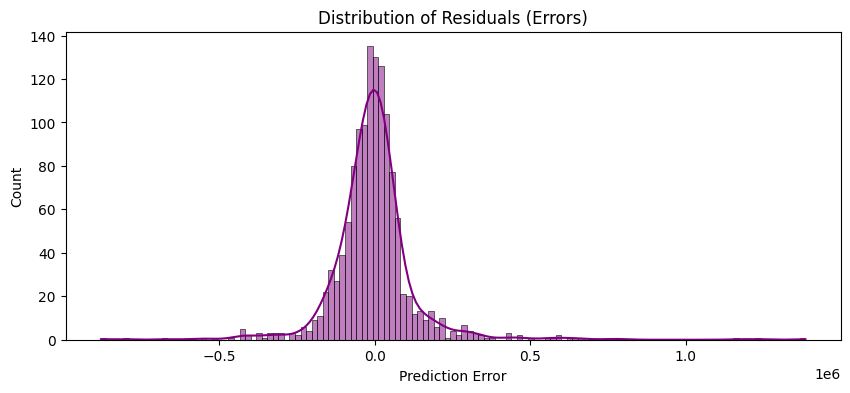

In [ ]:
# 1. Visualization of Actual vs Predicted Sales for the Improved Model
plt.figure(figsize=(10, 6))

# Scatter plot for improved test set results
sns.scatterplot(x=y_test_imp, y=y_pred_imp, alpha=0.6, color='teal')

# 2. Add perfect prediction line (y=x)
line_range = [y_test_imp.min(), y_test_imp.max()]
plt.plot(line_range, line_range, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Labels and formatting
plt.xlabel('Actual Weekly Sales', fontsize=12)
plt.ylabel('Predicted Weekly Sales', fontsize=12)
plt.title(f'Improved Model: Actual vs Predicted (R² = {new_r2:.4f})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Residual Distribution (Optional but helpful to see error patterns)
residuals = y_test_imp - y_pred_imp
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error')
plt.show()

## **Final Summary**

### **1. The Challenge: Baseline Underfitting**
Initially, our baseline Linear Regression model utilized basic features (Temperature, Fuel Price, CPI, Unemployment, and basic Date parts). This resulted in significant **underfitting**:
- **Baseline R² Score**: ~0.15
- **Problem**: The model failed to capture store-specific baselines and the complex temporal dependencies inherent in retail data.

### **2. The Solution: Advanced Feature Engineering**
To bridge the performance gap, we implemented several key feature engineering strategies:
- **Spatial Context**: Applied **One-Hot Encoding** to `Store` IDs, allowing the model to learn unique sales levels for each of the 45 locations.
- **Precise Seasonality**: Extracted `Week of Year` and calculated `Days_to_Holiday` to better capture pre-holiday shopping surges.
- **Economic Interactions**: Created an `Economic Stress Index` (Unemployment × CPI) to capture non-linear economic pressures.
- **Temporal Dynamics (Rolling Statistics)**: Introduced **Lagged Sales** and **4-week Rolling Averages** for Sales and Temperature. This provided the model with context regarding recent trends.

### **3. Results & Performance Jump**
The impact of these features was transformative, turning a weak baseline into a high-precision forecasting tool:
- **Improved R² Score**: **0.9388** (A **503% improvement** over baseline).
- **Improved MAE**: Reduced to approximately $81,034, down from over $430,000.
- **Visualization**: The Actual vs. Predicted scatter plot shows data points tightly clustered around the 45-degree identity line, indicating excellent model fit.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (50%)**
   - Proper data preprocessing and cleaning
   - Correct holiday feature engineering
   - Working linear regression implementation
   - Appropriate train/test splitting

2. **Model Performance (25%)**
   - Reasonable regression metrics (MAE, RMSE, R²)
   - Proper model evaluation and interpretation
   - Good generalization to test set

3. **Code Quality and Analysis (25%)**
   - Clean, readable code with comments
   - Meaningful visualizations and analysis
   - Proper interpretation of results
   - Good coding practices and documentation